<p style ="text-align:center">
    <img src="http://epecora.com.br/DataFiles/BannerUFPR.png" width="700" alt="PPGOLD/PPGMNE Python:INTRO"  />
</p>

# Data Science for Businnes - Aula 04

## Prof. Eduardo Pécora

## Train Test Split
Tempo estimado: **30** minutos

## Objetivos

Após completar esta aula, você será capaz de:

* Separar os dados em dados de treino e teste
* Usar o cross validation para avaliar a eficiência do modelo

## Bibliotecas

In [1]:
# importando a biblioteca pandas para manipulação de dados
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelBinarizer

# importando as bibliotecas do matplotlib para gerar gráficos
import matplotlib as mpl
import matplotlib.pyplot as plt

# Importando a biblioteca numpy e math que fornece funções matemáticas básicas
import numpy as np
import math

# Importando biblioteca do seaborn para gerar gráficos mais atraentes e informativos
import seaborn as sns

# Importando a classe LinearRegression do sklearn
# Essa classe implementa uma versão da regressão linear simples ou múltipla
# Usado para modelar a relação entre uma variável dependente contínua e uma ou mais variáveis independentes.
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Usado para exibir os gráficos gerados pela biblioteca Matplotlib diretamente no notebook, sem precisar abrir uma janela externa.
%matplotlib inline


## Obtendo dados

In [2]:
# Caminho do arquivo csv
caminho = "https://raw.githubusercontent.com/EduPekUfpr/PythonProject/refs/heads/main/Dados/MeuAutoLimpo.csv"

#Obtendo arquivo e passando-o para um dataframe
df = pd.read_csv(caminho)

In [3]:
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495
1,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500
2,1,164,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450


## Tranformação das variáveis

In [4]:
df_dummy = df.copy()

label_binarizer = LabelBinarizer()
# https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelBinarizer.html

dicotomica = df_dummy['num-of-doors']
label_binarizer.fit(dicotomica)
df_dummy['num-of-doors'] = label_binarizer.transform(dicotomica)

# renomeando as marcas
df_dummy['make'].replace({'bmw':'BMW', 'doge': 'dodge', 'VW':'volkswagen', 'volv1':'volvo' }, inplace = True)

# Crie uma instância do codificador OneHotEncoder
encoder = OneHotEncoder()

# Ajuste e transforme os dados da coluna "make"
poly_array = encoder.fit_transform(df_dummy[['make']])

# Crie um DataFrame Pandas com as variáveis dummy
poly_df = pd.DataFrame(poly_array.toarray(), columns=encoder.get_feature_names_out(['make']))

# Concatene o DataFrame dummy com os outros dados
df_dummy = pd.concat([df_dummy.drop('make', axis=1), poly_df], axis=1)

df_dummy.drop(['fuel-type', 'aspiration', 'body-style', 'drive-wheels',
               'engine-location', 'engine-type', 'num-of-cylinders', 'fuel-system'], axis =1, inplace = True)
df_dummy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 39 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   symboling           201 non-null    int64  
 1   normalized-losses   201 non-null    int64  
 2   num-of-doors        201 non-null    int64  
 3   wheel-base          201 non-null    float64
 4   length              201 non-null    float64
 5   width               201 non-null    float64
 6   height              201 non-null    float64
 7   curb-weight         201 non-null    int64  
 8   engine-size         201 non-null    int64  
 9   bore                201 non-null    float64
 10  stroke              201 non-null    float64
 11  compression-ratio   201 non-null    float64
 12  horsepower          201 non-null    float64
 13  peak-rpm            201 non-null    float64
 14  city-mpg            201 non-null    int64  
 15  highway-mpg         201 non-null    int64  
 16  price   

/tmp/ipykernel_1538/1431977921.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_dummy['make'].replace({'bmw':'BMW', 'doge': 'dodge', 'VW':'volkswagen', 'volv1':'volvo' }, inplace = True)


## Train Test Split

In [5]:
from sklearn.model_selection import train_test_split

# Original Data
X = df_dummy.drop(['price'], axis = 1)
Y = df_dummy['price']

# Split the data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25, random_state=42)

In [6]:
print("Dados de Treino: ", X_train.shape)
print("Dados de Teste : ", X_test.shape)

Dados de Treino:  (150, 38)
Dados de Teste :  (51, 38)


## Modelo Vazio

In [7]:
lm = LinearRegression()
lm

LinearRegression()

## Modelo Treinado

In [8]:
# Carregando o modelo
lm.fit(X_train, Y_train)

LinearRegression()

In [9]:
Y_test.columns = ['price']
Y_test.head()

,price
95,8249
15,41315
30,6855
158,9258
128,11850


## Avalia o modelo nas variáveis de treino e teste

In [10]:
# Exibindo o R^2

R2=lm.score(X_train,Y_train)
print("SCORE TREINO: %.4f" % R2)


R2=lm.score(X_test,Y_test)
print("SCORE TESTE: %.4f" % R2)

SCORE TREINO: 0.9449
SCORE TESTE: 0.9093


In [11]:
# Erros
Y_pred  = lm.predict(X_train)

mae = mean_absolute_error(Y_train, Y_pred)
mse = mean_squared_error(Y_train, Y_pred)
rmse = np.sqrt(mse)
mape = mae/Y_train.mean()

tt = "MAD  = %.3f \nMSRE = %.3f \nMSE   =  %.3f \nMAPE = %.3f" % (mae, rmse, mse, mape)

print('Erros do DF Treino')
print(tt)

# Erros
Y_pred  = lm.predict(X_test)

mae = mean_absolute_error(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)
rmse = np.sqrt(mse)
mape = mae/Y_test.mean()

tt = "MAD  = %.3f \nMSRE = %.3f \nMSE   =  %.3f \nMAPE = %.3f" % (mae, rmse, mse, mape)

print('\n\nErros do DF teste')
print(tt)

Erros do DF Treino
MAD  = 1149.451 
MSRE = 1592.162 
MSE   =  2534978.707 
MAPE = 0.091


Erros do DF teste
MAD  = 1976.630 
MSRE = 3127.794 
MSE   =  9783097.621 
MAPE = 0.132


Text(-10000, 2.5e-05, 'SCORE: 0.909343')

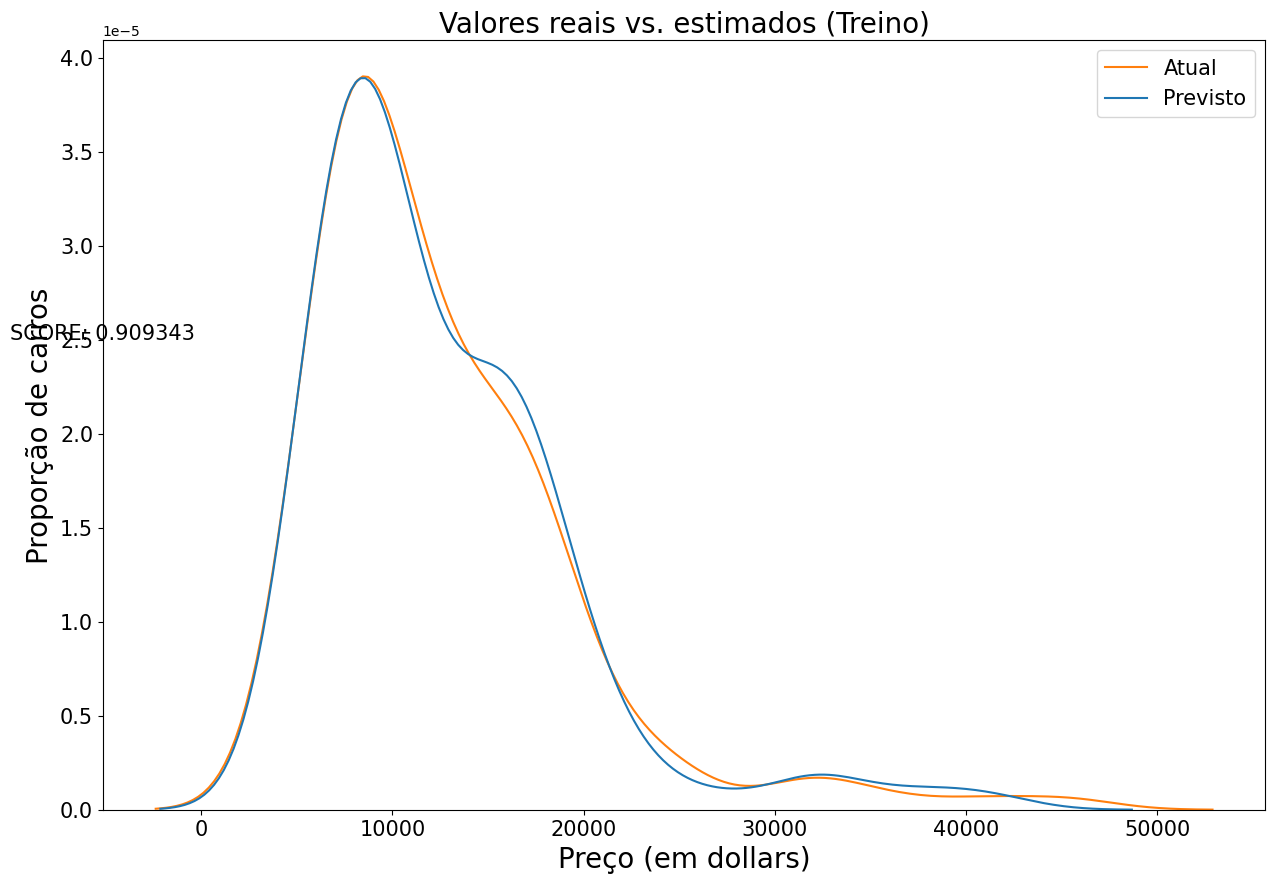

In [12]:
# Predizendo os valores
YHat = lm.predict(X_train)
YHat = pd.Series(YHat, name='YHat')

df = pd.concat([YHat, Y_train], axis=1)
plt.figure(figsize=(15, 10))

sns.kdeplot(data = df)

plt.title('Valores reais vs. estimados (Treino)', size = 20)
plt.xlabel('Preço (em dollars)', size = 20)
plt.ylabel('Proporção de carros', size = 20)
plt.yticks(size = 15)
plt.xticks(size = 15)
plt.legend(labels=["Atual","Previsto"], fontsize = 15, bbox_to_anchor=(1, 1))

tt = "SCORE: %4f" % R2

plt.text(-10000, 0.000025, tt, size = 15)

Text(-10000, 2.5e-05, 'SCORE: 0.909343')

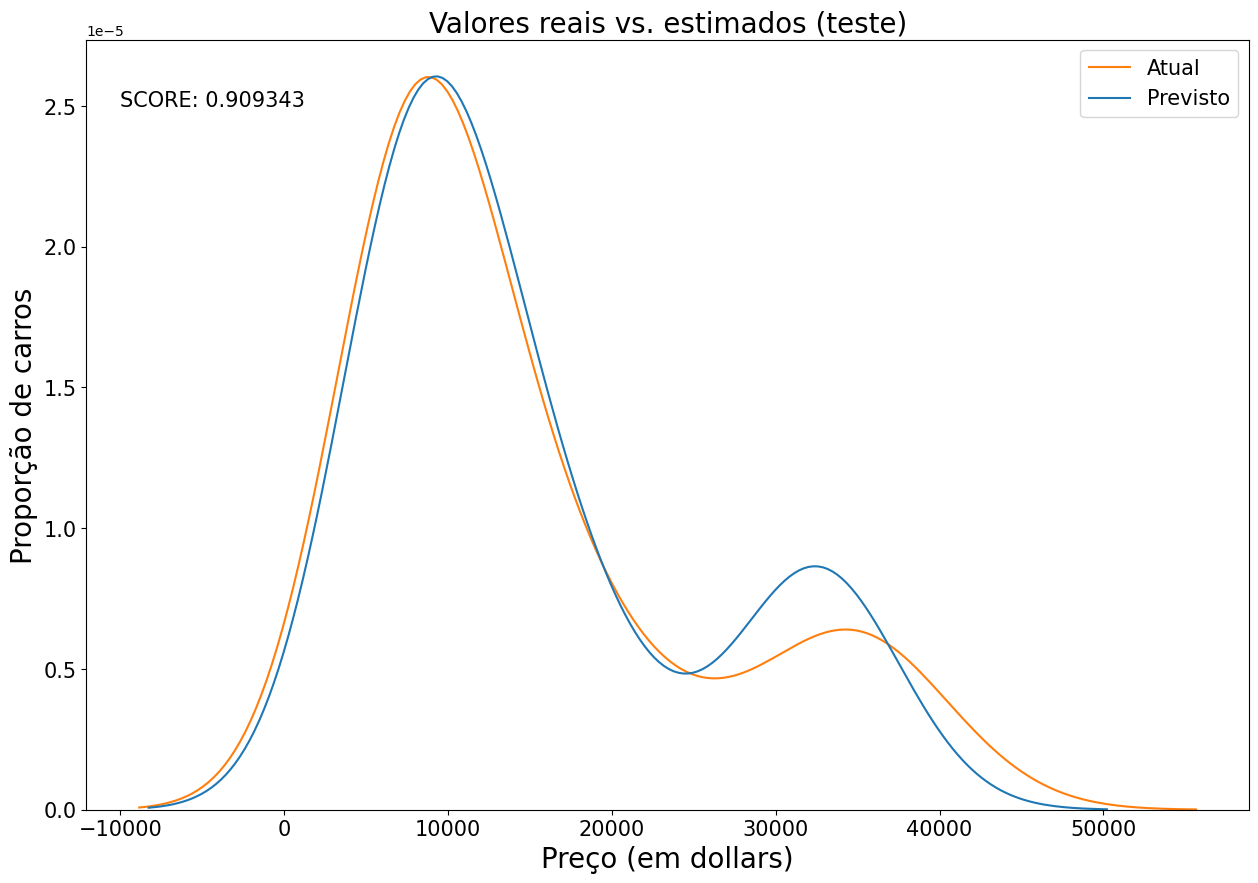

In [13]:
# Predizendo os valores
YHat = lm.predict(X_test)
YHat = pd.Series(YHat, name='YHat')

df = pd.concat([YHat, Y_test], axis=1)
plt.figure(figsize=(15, 10))

sns.kdeplot(data = df)

plt.title('Valores reais vs. estimados (teste)', size = 20)
plt.xlabel('Preço (em dollars)', size = 20)
plt.ylabel('Proporção de carros', size = 20)
plt.yticks(size = 15)
plt.xticks(size = 15)
plt.legend(labels=["Atual","Previsto"], fontsize = 15, bbox_to_anchor=(1, 1))

tt = "SCORE: %4f" % R2

plt.text(-10000, 0.000025, tt, size = 15)

# Overfitting


Incluindo 0 colunas

SCORE TREINO: 0.9449
SCORE TESTE: 0.9093
Incluindo 1 colunas

SCORE TREINO: 0.9451
SCORE TESTE: 0.9088
Incluindo 2 colunas

SCORE TREINO: 0.9475
SCORE TESTE: 0.9081
Incluindo 5 colunas

SCORE TREINO: 0.9488
SCORE TESTE: 0.9127
Incluindo 10 colunas

SCORE TREINO: 0.9526
SCORE TESTE: 0.9052
Incluindo 25 colunas

SCORE TREINO: 0.9631
SCORE TESTE: 0.9079
Incluindo 50 colunas

SCORE TREINO: 0.9915
SCORE TESTE: 0.6207
Incluindo 75 colunas

SCORE TREINO: 1.0000
SCORE TESTE: 0.2866
Incluindo 100 colunas

SCORE TREINO: 1.0000
SCORE TESTE: 0.5785
Incluindo 150 colunas

SCORE TREINO: 1.0000
SCORE TESTE: 0.6014
Incluindo 300 colunas

SCORE TREINO: 1.0000
SCORE TESTE: 0.6633
Incluindo 500 colunas

SCORE TREINO: 1.0000
SCORE TESTE: 0.6739


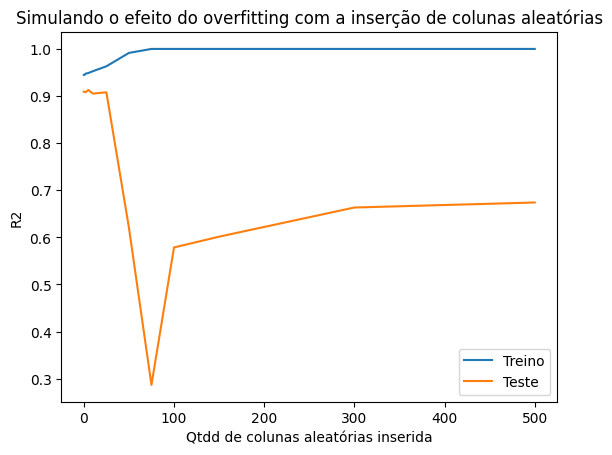

In [49]:
# Original Data
X = df_dummy.drop(['price'], axis = 1)
Y = df_dummy['price']

# Adicionando x colunas aleatórias no DF treino
col_random = [0,1,2,5,10,25,50,75,100,150,300,500]

r2_list_train = []
r2_list_test = []

for c in col_random:
    new_cols = {}
    for i in range(c):
        col_name = 'Random_' + str(i+1)
        new_cols[col_name] = np.random.randint(1, 100, size=len(X))

    X = pd.concat([X, pd.DataFrame(new_cols)], axis=1)

    # Split the data into training and testing sets
    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25, random_state=42)

    # lm_over
    lm_over = LinearRegression()
    lm_over

    # Treinando o modelo
    lm_over.fit(X_train, Y_train)

    # Exibindo o R^2
    print(f"Incluindo {c} colunas\n")

    R2_train = lm_over.score(X_train,Y_train)
    print("SCORE TREINO: %.4f" % R2_train)
    r2_list_train.append(R2_train)

    R2_test = lm_over.score(X_test,Y_test)
    print("SCORE TESTE: %.4f" % R2_test)
    r2_list_test.append(R2_test)

sns.lineplot(x=col_random, y=r2_list_train, label="Treino")
sns.lineplot(x=col_random, y=r2_list_test, label="Teste")

plt.title("Simulando o efeito do overfitting com a inserção de colunas aleatórias")
plt.xlabel("Qtdd de colunas aleatórias inserida")
plt.ylabel("R2")

plt.legend()
plt.show()

## Fique Conectado

- [![YouTube](https://img.icons8.com/ios-filled/40/000000/youtube-play.png)](https://www.youtube.com/@LigaDataScience/videos)  
  Explore nossos vídeos educacionais e webinars sobre ciência de dados, machine learning e inteligência artificial. Inscreva-se para não perder nenhuma atualização!

- [![LinkedIn](https://img.icons8.com/ios-filled/40/000000/linkedin.png)](https://www.linkedin.com/company/liga-data-science-ufpr/)  
  Siga-nos no LinkedIn para as últimas novidades, oportunidades de carreira e networking profissional no campo da ciência de dados.

- [![Instagram](https://img.icons8.com/ios-filled/40/000000/instagram-new.png)](https://www.instagram.com/ligadatascience/)  
  Confira nosso Instagram para conteúdos dos bastidores, destaques de eventos e o dia a dia da Liga Data Science. Faça parte da nossa jornada!


## Autores

<a href="https://www.linkedin.com/in/eduardopecora/" target="_blank">Eduardo Pecora</a>

## Referências:

* Documentação da biblioteca <a href="https://pandas.pydata.org/docs/">Pandas</a>
* Documentação do método <a href=https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html>cross_val_score</a>
* Documentação do método <a href=https://scikit-learn.org/dev/modules/generated/sklearn.model_selection.KFold.html>KFold</a>
* Documentação do método <a href=https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html>train_test_split</a>



## Log de modificações

| Data | Versão | Modificado por | Descrição |
| -----------| ------- | ---------- | ---------------------------------- |
| 24-04-2024       | 1.0     | Eduardo Pecora    | Inicial               |
| 29-03-2026       | 1.1     | Eduardo Pecora    | Overfiting               |